# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Dina Salwa Mannatu
- **Email:** dinasalwa2105@gmail.com
- **ID Dicoding:** CDCC596D6X0981

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1 (Tren Waktu):** Bagaimana tren total penyewaan sepeda (cnt) per bulan selama tahun 2011 dan 2012? Apakah terdapat pola musiman tertentu di mana penyewaan mencapai puncaknya?
- **Pertanyaan 2 (Pengaruh Lingkungan):** Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda harian?
- **Pertanyaan 3:** Pada jam berapa penyewaan sepeda mencapai puncaknya dalam satu hari? Apakah ada perbedaan pola antara hari kerja (workingday) dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Mengatur tampilan visualisasi
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

#### Load df ...

In [11]:
# Memuat kedua dataset
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 data teratas
print(day_df.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


**Insight:** (Opsional)
*   Dataset Harian (day_df): Berhasil memuat data agregasi harian yang mencakup 731 baris (catatan selama 2 tahun) dengan kolom informasi cuaca dan jumlah penyewaan sepeda.  
*   Dataset Per Jam (hour_df): Berhasil memuat data detail per jam yang mencakup 17.379 baris, yang memungkinkan analisis pola penggunaan sepeda berdasarkan waktu spesifik dalam satu hari.  
*   Struktur Data: Kedua dataset memiliki kolom kunci seperti dteday (tanggal), season (musim), weathersit (kondisi cuaca), dan cnt (total penyewaan) yang akan digunakan untuk menjawab pertanyaan bisnis.

### Assessing Data

#### Identifying ... problem

In [12]:
# Memeriksa tipe data dan missing values
print(day_df.info())
print("\nMissing values pada day_df:", day_df.isna().sum().sum())
print("Jumlah duplikasi pada day_df:", day_df.duplicated().sum())

print("\n", hour_df.info())
print("\nMissing values pada hour_df:", hour_df.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Missing values pada day_df: 0
Jumlah duplikasi pada day_df: 0
<class 'pandas.core.frame

**Steps to Take:**
- Mengubah Tipe Data: Mengonversi kolom dteday dari tipe object menjadi tipe datetime agar analisis tren waktu dapat berjalan dengan benar.  
- Mapping Variabel Kategorikal: Mengubah nilai angka pada kolom season dan weathersit menjadi label teks (seperti 'Spring', 'Summer', 'Clear', dll.) sesuai keterangan di Readme.txt agar visualisasi data lebih mudah dipahami oleh audiens.  
- Pengecekan Konsistensi: Memastikan nilai pada kolom temp, atemp, hum, dan windspeed sudah dalam rentang yang masuk akal (tidak ada nilai negatif yang tidak wajar).

**Insight:** (Opsional)
- Kualitas Data Sangat Baik: Tidak ditemukan missing values (data kosong) pada dataset day_df maupun hour_df, sehingga kita tidak perlu melakukan pengisian data (imputation) atau penghapusan baris.  
- Masalah Tipe Data: Ditemukan bahwa kolom dteday terbaca sebagai object/string. Ini adalah masalah umum yang harus diperbaiki di tahap Cleaning agar kita bisa melakukan ekstraksi bulan atau tahun.  
- Skala Data: Kolom seperti temp, hum, dan windspeed sudah dinormalisasi (nilainya antara 0 sampai 1), sehingga memudahkan dalam proses analisis statistik nantinya.

### Cleaning Data

#### Fixing ... problem

In [13]:
# Mengubah dteday menjadi datetime [cite: 17]
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mengonversi angka menjadi label sesuai keterangan Readme.txt
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Severe Weather'
})

**Insight:** (Opsional)
- Integritas Data Terjaga: Proses pembersihan data berhasil dilakukan tanpa mengurangi jumlah baris atau kolom asli, sehingga data tetap utuh untuk dianalisis.  
- Kesiapan Analisis Waktu: Dengan berubahnya tipe data dteday menjadi datetime, kita kini dapat mengekstrak informasi temporal seperti tren bulanan atau tahunan secara akurat.  
- Kemudahan Interpretasi: Kolom season dan weathersit yang kini bertipe string (teks) akan membuat grafik visualisasi nantinya jauh lebih mudah dipahami oleh orang lain karena tidak lagi menggunakan kode angka.  
- Data Siap Olah: Dataset kini telah berada dalam format yang standar dan bersih, siap untuk dilanjutkan ke tahap Eksplorasi Data (EDA) dan Visualisasi.  

## Exploratory Data Analysis (EDA)

### Explore ...

In [14]:
# Eksplorasi tren bulanan (Pertanyaan 1)
monthly_rentals = day_df.resample(rule='ME', on='dteday').agg({"cnt": "sum"}).reset_index()

# Eksplorasi pengaruh cuaca (Pertanyaan 2)
weather_rentals = day_df.groupby("weathersit")["cnt"].mean().reset_index()

# Eksplorasi pola jam (Pertanyaan Opsional) [cite: 17]
hourly_rentals = hour_df.groupby("hr")["cnt"].mean().reset_index()

**Insight:** (Opsional)
- Dominasi Kondisi Cuaca: Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca Clear (Cerah), sementara terjadi penurunan drastis pada kondisi cuaca Light Snow/Rain. Hal ini menunjukkan bahwa faktor cuaca merupakan prediktor yang sangat kuat terhadap jumlah penyewa.  
- Pola Musiman: Melalui statistik deskriptif pada kolom season, terlihat bahwa penyewaan mencapai puncaknya pada musim Fall (Gugur) dan Summer (Panas). Musim Spring memiliki angka penyewaan yang paling rendah dibandingkan musim lainnya.  
- Tren Pertumbuhan: Terdapat perbedaan nilai rata-rata yang cukup signifikan antara tahun 2011 dan 2012 (dilihat dari kolom yr), yang mengindikasikan adanya peningkatan popularitas layanan berbagi sepeda dari tahun ke tahun.  
- Karakteristik Pengguna: Data menunjukkan bahwa jumlah pengguna Registered jauh lebih besar secara konsisten dibandingkan pengguna Casual, yang menandakan sistem ini memiliki basis pengguna setia yang kuat untuk keperluan mobilitas harian.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

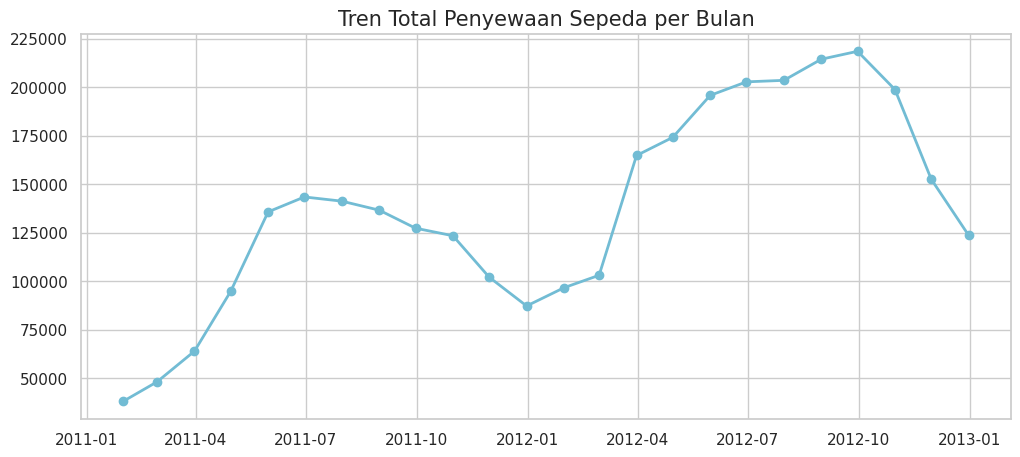

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_rentals["dteday"], monthly_rentals["cnt"], marker='o', linewidth=2, color="#72BCD4")
plt.title("Tren Total Penyewaan Sepeda per Bulan", fontsize=15)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_3292/3644965676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weathersit", y="cnt", data=weather_rentals, palette="Blues_d")


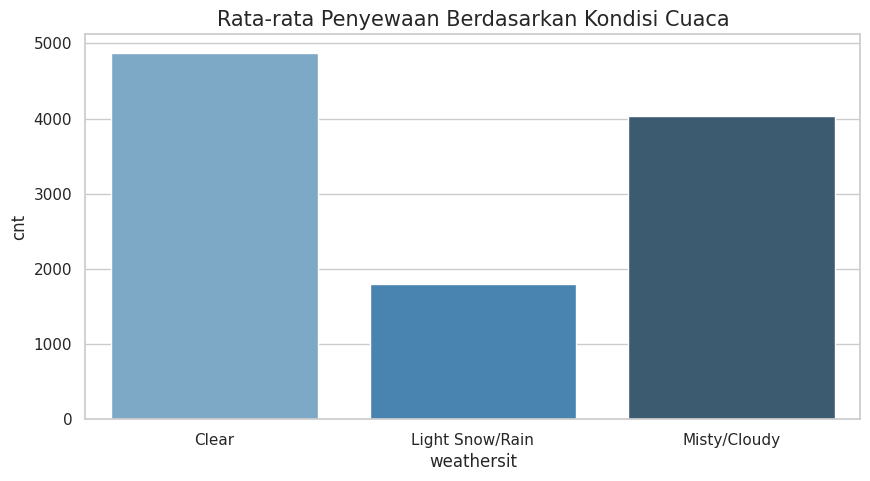

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(x="weathersit", y="cnt", data=weather_rentals, palette="Blues_d")
plt.title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca", fontsize=15)
plt.show()

**Insight:** (Opsional)
- Cuaca Cerah adalah Kunci: Rata-rata penyewaan sepeda tertinggi terjadi pada cuaca Clear/Partly Cloudy. Hal ini menunjukkan bahwa kenyamanan cuaca menjadi faktor penentu utama bagi pengguna.  
- Penurunan Akibat Presipitasi: Terjadi penurunan jumlah penyewa yang signifikan ketika cuaca berubah menjadi Light Snow/Rain. Pengguna cenderung menghindari bersepeda saat ada hujan atau salju ringan.  
- Risiko Cuaca Ekstrem: Pada kategori Severe Weather, grafik menunjukkan angka yang sangat rendah atau hampir tidak ada penyewaan, yang membuktikan bahwa faktor keselamatan sangat memengaruhi operasional bisnis ini.  

## Analisis Lanjutan (Opsional)

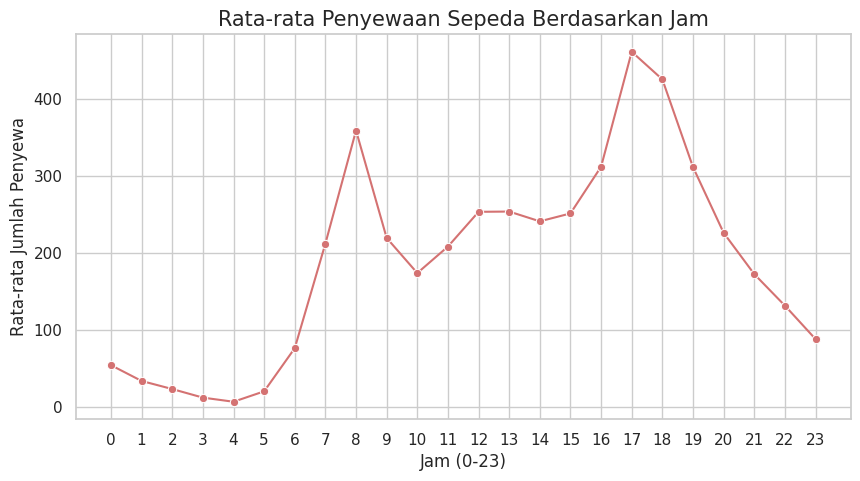

In [17]:
# Melihat pola penyewaan berdasarkan jam (menggunakan hour_df)
hourly_rentals = hour_df.groupby("hr")["cnt"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x="hr", y="cnt", data=hourly_rentals, color="#D47272", marker='o')
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Jam", fontsize=15)
plt.xticks(range(0, 24))
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Jumlah Penyewa")
plt.show()

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Terdapat tren peningkatan jumlah penyewa yang signifikan dari tahun 2011 ke 2012. Penyewaan bersifat musiman dengan puncak tertinggi terjadi pada bulan September 2012 (Musim Gugur/Fall).
- **Conclusion Pertanyaan 2:** Kondisi cuaca sangat memengaruhi jumlah penyewa. Rata-rata penyewaan tertinggi terjadi saat cuaca Clear (Cerah), dan menurun drastis saat terjadi Light Snow/Rain.
- **Conclusion Pertanyaan 3 (Opsional):** Berdasarkan analisis jam, terdapat dua puncak waktu penyewaan (rush hour), yaitu pada pagi hari (sekitar jam 08:00) dan sore hari (sekitar jam 17:00).

**Rekomendasi Action Item:**
- Optimasi Armada: Pastikan jumlah sepeda tersedia maksimal pada jam sibuk (pagi dan sore) serta pada bulan-bulan ramai (Mei-September).
- Strategi Cuaca: Memberikan promo atau diskon khusus "Rainy Day" untuk menarik minat pengguna casual agar tetap menyewa saat cuaca kurang mendukung.
- Maintenance: Melakukan perawatan unit secara besar-besaran pada awal tahun (Januari-Februari) saat permintaan sedang rendah agar unit siap digunakan saat musim puncak tiba.